In [1]:
import torch
import numpy as np
print(torch.cuda.is_available())
import torch.nn as nn
import torch.nn.functional as F
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
print(torch.cuda.get_device_name(0))
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1F1F1F'
plt.rcParams['axes.facecolor'] = '#1F1F1F'
plt.rcParams['savefig.facecolor'] = '#1F1F1F'

True
Quadro M1200


In [53]:
import torch
import torch.nn.functional as F

# Two tokens, embedding dim = 1
q0, k0, v0 = 1.0, 2.0, 10.0
q1, k1, v1 = 3.0, 5.0, 20.0

q = torch.tensor([[q0], [q1]])  # (T, d)
k = torch.tensor([[k0], [k1]])
v = torch.tensor([[v0], [v1]])

print("Embeddings:")
print("q:", q.squeeze().tolist())
print("k:", k.squeeze().tolist())
print("v:", v.squeeze().tolist())

# Raw attention scores
attn = q @ k.T
print("\nRaw attention:\n", attn)

# Strictly causal mask (no self, no future)
T = attn.size(0)
mask = torch.triu(torch.ones(T, T), diagonal=1).bool()  # includes diagonal

#mask = torch.zeros((T, T), dtype=torch.bool)
attn = attn.masked_fill(mask, float('-inf'))

#attn = torch.ones(T,T)
print("\nMasked attention (no future, no self):\n", attn)

# Softmax with safe handling: replace rows that are all -inf with zeros
attn_probs = F.softmax(attn, dim=-1)
attn_probs = torch.nan_to_num(attn_probs, nan=0.0)  # replace NaNs with 0
print("\nAttention probs:\n", attn_probs)

# Weighted sum
out = attn_probs @ v
print("\nOutput:\n", out.squeeze().tolist())


Embeddings:
q: [1.0, 3.0]
k: [2.0, 5.0]
v: [10.0, 20.0]

Raw attention:
 tensor([[ 2.,  5.],
        [ 6., 15.]])

Masked attention (no future, no self):
 tensor([[ 2., -inf],
        [ 6., 15.]])

Attention probs:
 tensor([[1.0000e+00, 0.0000e+00],
        [1.2339e-04, 9.9988e-01]])

Output:
 [10.0, 19.99876594543457]


In [47]:
randommatrix = 10 * torch.ones(4,4)
abc = torch.zeros(4,4, dtype=torch.bool)
abc[0:2, 2:4] = True
randommatrix = randommatrix.masked_fill(abc, float('-inf'))
print(randommatrix)

tensor([[10., 10., -inf, -inf],
        [10., 10., -inf, -inf],
        [10., 10., 10., 10.],
        [10., 10., 10., 10.]])


In [33]:
np.exp(6) / (np.exp(6) + np.exp(15)), np.exp(15) / (np.exp(6) + np.exp(15))

(np.float64(0.00012339457598623172), np.float64(0.9998766054240138))

In [10]:
uppertriangle = torch.tril(torch.ones(4,4)).masked_fill(torch.tril(torch.ones(4,4))==0, float('-inf'))
print(uppertriangle)
final_mask = torch.tril(torch.ones(4,4)).bool()
print(torch.zeros_like(final_mask, dtype=torch.float32).masked_fill_(~final_mask, float("-inf")))
print(~final_mask)


tensor([[1., -inf, -inf, -inf],
        [1., 1., -inf, -inf],
        [1., 1., 1., -inf],
        [1., 1., 1., 1.]])
tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])
tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])


torch.Size([1, 10, 12, 64, 64])
torch.Size([1, 10, 12, 64, 64])
torch.Size([1, 10, 12, 64, 64])
torch.Size([1, 10, 16, 64, 64]) torch.Size([1, 10, 16, 64, 64]) torch.Size([1, 10, 16, 64, 64])
tensor(-4.7193) tensor(4.1782) tensor(0.0024) tensor(0.9992)
tensor(-4.7616) tensor(4.5338) tensor(-0.0006) tensor(0.9996)


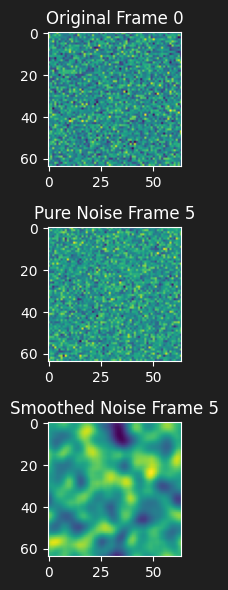

In [ ]:
import torch
import torch.nn as nn

def prior_purenoise(data, fromframe=4):
    """
    Replace frames >= fromframe with pure Gaussian noise.
    data: (B, C, T, H, W)
    """
    B, C, T, H, W = data.shape
    noise = torch.randn((B, C, T - fromframe, H, W), device=data.device, dtype=data.dtype)
    data[:, :, fromframe:] = noise
    return data

def prior_smoothnoise(data, fromframe=4, smooth_passes=3):
    B, C, T, H, W = data.shape
    noise = torch.randn((B, C, T - fromframe, H, W), device=data.device, dtype=data.dtype)
    def circular_avg_pool3d(x, kernel_size=(5,5,5), stride=1, passes=1):
        pad_t, pad_h, pad_w = kernel_size[0]//2, kernel_size[1]//2, kernel_size[2]//2
        for _ in range(passes):
            x = F.pad(x, (pad_w, pad_w, pad_h, pad_h, pad_t, pad_t), mode="circular")
            x = F.avg_pool3d(x, kernel_size=kernel_size, stride=stride)
        return x
    
    for _ in range(smooth_passes):
        print(noise.shape)
        noise = circular_avg_pool3d(
            noise,
            kernel_size=(5, 5, 5),
            stride=1,
        )
    noise = noise / noise.std()  # Normalize to std=1
    data[:, :, fromframe:] = noise
    return data


# Test
data = torch.randn(1, 10, 16, 64, 64)  # (B, C, T, H, W)
data_pure = prior_purenoise(data.clone(), fromframe=4)
data_smooth = prior_smoothnoise(data.clone(), fromframe=4)

print(data.shape, data_pure.shape, data_smooth.shape)
fig, ax = plt.subplots(3, 1, figsize=(8, 6))
ax[0].imshow(data[0, 0, 0].cpu(), cmap='viridis')
ax[0].set_title('Original Frame 0')
ax[1].imshow(data_pure[0, 0, 5].cpu(), cmap='viridis')
ax[1].set_title('Pure Noise Frame 5')
ax[2].imshow(data_smooth[0, 0, 5].cpu(), cmap='viridis')
ax[2].set_title('Smoothed Noise Frame 5')
plt.tight_layout()
print(data_smooth.min(), data_smooth.max(), data_smooth.mean(), data_smooth.std())
print(data_pure.min(), data_pure.max(), data_pure.mean(), data_pure.std())

In [16]:
import sys
sys.path.append('../')
%load_ext autoreload
%autoreload
from modelComp.FluidGPT_FM import FluidGPT_FM
from modelComp.utils import ACT_MAPPER, SKIPBLOCK_MAPPER
model = FluidGPT_FM(
    data_dim=[1, 16, 2, 128, 128],
    emb_dim=96,
    embedder_type='linear',  # options: "linear", "conv_v1", "conv_v2"
    patch_size=(8, 8),
    hiddenout_dim=512,
    flowmatching_emb_dim=512,
    depth=2,
    stage_depths=[9,9,8,9,9],
    num_heads=[16,32,64,32,16],
    window_size=4,
    use_flex_attn=True,
    causal_attn=True,
    act=ACT_MAPPER['gelu'],
    skip_enable=True,
    skip_connect=SKIPBLOCK_MAPPER['convnext'],
    #norm_layer=torch.nn.GroupNorm,
    gradient_flowthrough=[True, True, True]
).to('cuda')
print(sum(p.numel() for p in model.parameters() if p.requires_grad) // 1_000_000, "M parameters")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
48 M parameters


In [6]:
shape = (1, 2, 16, 128, 128)
xtest = torch.randn(shape)
xtest = xtest.to('cuda')
#print(xtest.shape)
t = torch.rand((1), device='cuda')
#print(t)
y = model(xtest, t)
ytrue = torch.randn_like(y)
loss = nn.MSELoss()(y, ytrue)
loss.backward()
losscalc = loss.item()
print(losscalc)
print(y.mean(), y.std(), y.shape)

1.207863211631775
tensor(-0.0071, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.4614, device='cuda:0', grad_fn=<StdBackward0>) torch.Size([1, 2, 16, 128, 128])


In [2]:
torch.linspace(0, 10, steps=5)

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])

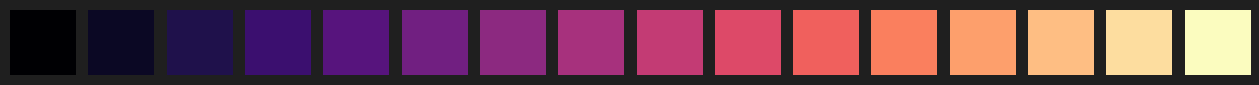

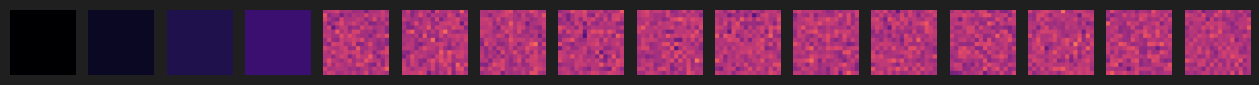

In [6]:

data = torch.ones((16,2,128,128), device='cuda') * torch.linspace(-8, 8, steps=16, device='cuda').view(-1,1,1,1)
fig, axs = plt.subplots(1,16, figsize=(16,5))
for i in range(16):
    axs[i].imshow(data[i][0].cpu().detach().numpy(), vmin=-8, vmax=8, cmap='magma')
    axs[i].axis('off')

def checkerboard_noise(data, fromframe=4):
    # generate checkerboard noise
    noise = torch.randn(size=(data.shape[0] - fromframe, data.shape[1], data.shape[2] // 8, data.shape[3] // 8), device=data.device)
    noise = noise.repeat_interleave(8, dim=2).repeat_interleave(8, dim=3)
    data[fromframe:] = noise
    return data

data = checkerboard_noise(data)
fig, axs = plt.subplots(1,16, figsize=(16,5))
for i in range(16):
    axs[i].imshow(data[i][0].cpu().detach().numpy(), vmin=-8, vmax=8, cmap='magma')
    axs[i].axis('off')

In [11]:
abc = torch.triu(torch.ones(3, 3))
print(abc)
abc = abc.masked_fill(abc == 0, float('-inf'))
print(abc)

tensor([[1., 1., 1.],
        [0., 1., 1.],
        [0., 0., 1.]])
tensor([[1., 1., 1.],
        [-inf, 1., 1.],
        [-inf, -inf, 1.]])


In [2]:
shape1 = torch.randn(2, 3, 5, 8)
shape2 = torch.randn(2, 3, 5, 4)
shape3 = torch.concat((shape1, shape2), dim=3)
print(shape3.shape)

torch.Size([2, 3, 5, 12])


In [2]:
batch_size = 8
channels = 2
timesteps = 16 
height = 128
width = 128
shape = (batch_size, channels, timesteps, height, width)

amount = 10

In [3]:
for i in enumerate(range(amount)):
    gaussian_noise_np = np.random.normal(size=shape)
print(gaussian_noise_np.shape, end='\r')


In [4]:
for i in enumerate(range(amount)):
    gaussian_noise_torch = torch.randn(batch_size, channels, timesteps, height, width)
    print(i, gaussian_noise_torch.shape, end='\r')

print(gaussian_noise_torch.shape)  # Output: torch.Size([4, 3, 64, 64])


torch.Size([8, 2, 16, 128, 128]), 128])


In [8]:
import sys
import os
import torch
sys.path.append('../../flow_matching/')
print(sys.path[-1])
print(os.listdir(sys.path[-1]))
from examples.image.models.unet import UNetModel
model = UNetModel(in_channels = 2,
        model_channels = 48,
        out_channels = 2,
        num_res_blocks = 1,
        attention_resolutions = [0,0,8],#[2, 4, 8],
        dropout = 0.1,
        channel_mult = [1, 2, 2, 2],
        num_classes = None,
        use_checkpoint = False,
        num_heads = 4,
        num_head_channels = 48,
        use_scale_shift_norm = True,
        resblock_updown = True,
        use_new_attention_order = True,
        with_fourier_features = False,
        dims = 3
)
checkpoint = torch.load('../../output/1709-14hr/FluidGPT_FM/1k592osu/epoch=0011-val_SS_loss_checkpoint=0.009457.ckpt', map_location='cpu')
new_state_dict = {k.replace('model.', ''): v for k, v in checkpoint['state_dict'].items()}
model.load_state_dict(new_state_dict)

../../flow_matching/
['setup.py', 'tests', 'docs', '.pre-commit-config.yaml', 'LICENSE', 'CONTRIBUTING.md', '.github', 'environment.yml', 'assets', '.flake8', 'flow_matching', 'examples', 'README.md', '.gitignore', 'CHANGELOG.md', 'CODE_OF_CONDUCT.md', '.git', 'RELEASE.md']


<All keys matched successfully>

In [5]:
model.resnorms_up

ModuleList(
  (0): ModuleList(
    (0-11): 12 x LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (1): ModuleList(
    (0-11): 12 x LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
)